# Øving 9: Nettverksanalyse (10 poeng)


Denne uken skal vi jobbe med OpenStreetMap data og utføre en nettverksanalyse i Python.

## Oppgave 1: Lese inn data

I data-mappen ligger det to filer:

- `start.csv`
- `slutt.csv`

Les de inn i to dataframes som heter henholdsvis `start` og `slutt`.

In [22]:
# imports
import pathlib
import pandas as pd
from shapely.geometry import Point, LineString
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
from geopy.geocoders import Nominatim
import osmnx as ox

In [23]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

NOTEBOOK_PATH = pathlib.Path().resolve()
DATA_MAPPE = NOTEBOOK_PATH / "data"

# Leser inn data
start = pd.read_csv(DATA_MAPPE / "start.csv")
slutt = pd.read_csv(DATA_MAPPE / "slutt.csv")

In [24]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!

## Oppgave 2: Lokaliser punktene

Du skal nå localisere punktene på to ulike måter:

### 2a) Visuell lokalisering

Her skal du plotte punktene på ett kart med et bakgrunnskart og se hvor punktene befinner seg. Begge datasettene er i utgangspunktet i EPSG:4326.

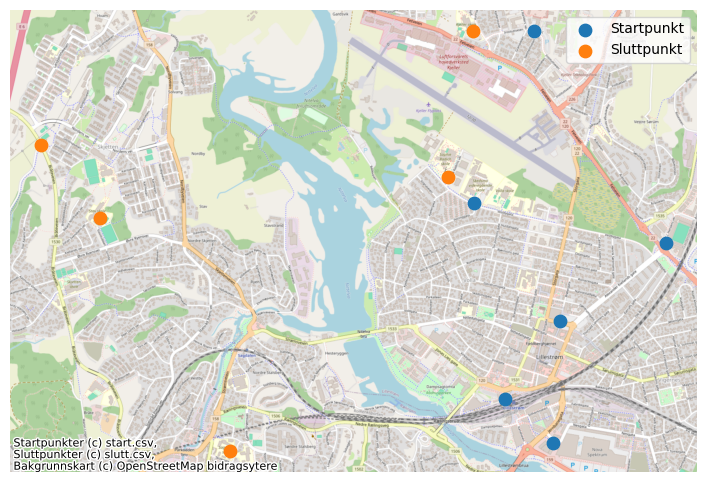

In [25]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

# Legger til geometrikolonne i dataframene
start["geometry"] = start.apply(lambda row: Point(row["lon"], row["lat"]), axis=1)
slutt["geometry"] = slutt.apply(lambda row: Point(row["lon"], row["lat"]), axis=1)

# Konverterer dataframes til geodataframes
start = gpd.GeoDataFrame(start, geometry="geometry", crs="EPSG:4326")
slutt = gpd.GeoDataFrame(slutt, geometry="geometry", crs="EPSG:4326")

# Re-projiserer punktene til EPSG:3857 for bakgrunnskart
start_3857 = start.to_crs(3857)
slutt_3857 = slutt.to_crs(3857)

fig, ax = plt.subplots(figsize=(10, 6))

# Plotter punktene
start_3857.plot(ax=ax, markersize=80, label="Startpunkt")
slutt_3857.plot(ax=ax, markersize=80, label="Sluttpunkt")

# Legger til bakgrunnskart
ctx.add_basemap(ax=ax, zoom=15, source=ctx.providers.OpenStreetMap.Mapnik, 
                attribution=(
                    "Startpunkter (c) start.csv, \n"
                    "Sluttpunkter (c) slutt.csv, \n"
                    "Bakgrunnskart (c) OpenStreetMap bidragsytere"
))

plt.legend()
ax.set_axis_off()

### 2b) Geokoding

Du skal nå bruke omvendt geokoding av punktene ([se hint fra geopy-dokumentasjonen](https://geopy.readthedocs.io/en/stable/index.html?highlight=reverse#module-geopy.geocoders)) og printe ut adressene fra minst ett av lagene med punkter.

In [26]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

# Oppretter en geolocator
geolocator = Nominatim(user_agent="simen_oving9", timeout=10)

# Skriver ut adresser for koordinatparene i slutt
for i, j in slutt.iterrows():
    lon = j.geometry.x
    lat = j.geometry.y
    location = geolocator.reverse((lat, lon))
    print(location.address)

Bråteveien, Skjetten, Lillestrøm, Akershus, 2013, Norge
25, Frydenlundsgata, Strømmen, Lillestrøm, Akershus, 2010, Norge
Kjeller skole, Fetveien, Volla, Kjeller, Lillestrøm, Akershus, 2007, Norge
Sophie Radichs vei, Volla, Lillestrøm, Akershus, 2003, Norge
Stav skole, Rikard Nordraaks vei, Skjetten, Lillestrøm, Akershus, 2013, Norge


## Oppgave 3: OpenStreetMap

Du skal nå hente ut data fra OpenStreetMap for området hvor punktene befinner seg. Bruk bare veinettet for bil.

Spesifiser først utstrekningen til området du skal laste inn data fra som et Shapely Polygon. Utstrekningen skal være et polygon som er lagret i variablen `utstrekning`.

- Merk at noen av rutene kan gå utover omfanget av punktdatasettene!
- Legg til litt buffer rundt punktene for å laste ned grafen, slik at du dekker alle rutene mellom punktene.
- Se hint fra denne ukens oppgavesid om hvordan du definerer utstrekningen.

In [27]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

# Samler alle punkter i en GeoDataFrame
punkter = pd.concat([start, slutt], ignore_index=True)
punkter = gpd.GeoDataFrame(punkter, geometry=punkter.geometry, crs="EPSG:4326")

# Re-projiserer punktene til metrisk CRS
punkter = punkter.to_crs("EPSG:25832")

# Lager polygon med buffer på 600 meter
utstrekning = punkter.union_all().convex_hull.buffer(600)
utstrekning = gpd.GeoDataFrame(geometry=[utstrekning], crs="EPSG:25832").to_crs(4326).geometry.iloc[0]

- Bruk polygonet til laste inn det kjørbare veinettet med `.graph_from_polygon()`-funksjonen
- Husk å spesifiser riktig `network_type`
- se [osmnx-dokumentasjonen](https://osmnx.readthedocs.io/en/stable/osmnx.html#osmnx.core.graph_from_polygon) for mer detaljer
- lagre veinettet i en variabel med navn `graph`

In [28]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

# Henter nettverksgraf for utstrekning polygon
graph = ox.graph_from_polygon(utstrekning, network_type="drive")

In [29]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!

## Oppgave 4: Reprojisering

Reprojiser dataene til en UTM-projeksjon og plot et kart med veinettet, start-punktene i en farge og slutt-punktene i en annen farge

In [30]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

# Transformerer grafen til UTM
graph = ox.project_graph(graph)

# Henter re-projiserte noder og kanter
nodes, edges = ox.graph_to_gdfs(graph)

# Re-projiserer punktene til samme CRS som kantene
start = start.to_crs(edges.crs)
slutt = slutt.to_crs(edges.crs)

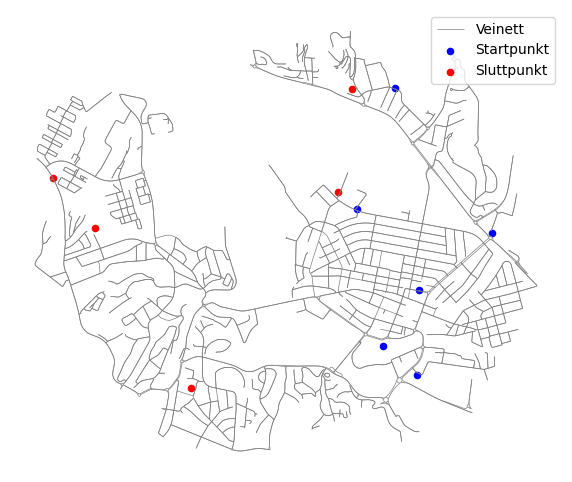

In [31]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

# Plotter punkter og veinett
fig, ax = plt.subplots(figsize=(10,6))

edges.plot(ax=ax, linewidth=0.5, color="grey", label="Veinett")
start.plot(ax=ax, markersize=20, color="blue", label="Startpunkt")
slutt.plot(ax=ax, markersize=20, color="red", label="Sluttpunkt")

ax.set_axis_off()
plt.legend()
plt.show()

## Oppgave 5: Korteste vei

Regn ut korteste vei mellom _alle_ start- og slutt-punkt ved hjelp av lengden på veisegmentene.

- For å finne de korteste rutene, bør du finne de nærmeste nodene fra grafen for både start- og destinasjonspunktene.
- Merk: hvis den nærmeste noden er den samme for både start- og destinasjonspunktet, bør du hoppe over beregningen av den korteste ruten.
- Etter ruteberegningen bør du legge til de korteste rutene som LineString-geometrier i en GeoDataFrame kalt `ruter`.
- Du bør bruke den projiserte grafen som nettverk for analysene.
- Husk å bruke informative variabelnavn og å kommentere koden din!

In [32]:
start.crs

<Projected CRS: EPSG:32632>
Name: WGS 84 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 6°E and 12°E, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Austria. Cameroon. Denmark. Equatorial Guinea. France. Gabon. Germany. Italy. Libya. Liechtenstein. Monaco. Netherlands. Niger. Nigeria. Norway. Sao Tome and Principe. Svalbard. Sweden. Switzerland. Tunisia. Vatican City State.
- bounds: (6.0, 0.0, 12.0, 84.0)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [33]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

# Finner nærmeste noder til start- og sluttpunktene i grafen
start_nodes = ox.nearest_nodes(graph, start.geometry.x, start.geometry.y)
slutt_nodes = ox.nearest_nodes(graph, slutt.geometry.x, slutt.geometry.y)

# Definerer en liste rutene kan lagres i
rute_liste = []
rute_id = 0
# Nestet løkke som iterer over start- og sluttpunkter
for i, on in enumerate(start_nodes):
    for j, dn in enumerate(slutt_nodes):

        # Hopper over tilfeller der nærmeste node er samme for start- og sluttpunkt
        if on == dn:
            continue

        # Beregner korteste vei mellom nodene basert på lengde
        rute = ox.shortest_path(graph, on, dn, weight="length")
        rute_noder = nodes.loc[rute]

        # Lager LineString-geometri av ruten
        rute_linje = LineString(rute_noder.geometry.values)

        # Legger til ruten i listen over ruter
        rute_liste.append({
            "rute_id": rute_id, 
            "start_idx": i,
            "slutt_idx": j,
            "start_node": on,
            "slutt_node": dn,
            "geometry": rute_linje
        })
        rute_id += 1

# Konverterer alle rutene til en GeoDataFrame
ruter = gpd.GeoDataFrame(rute_liste, crs=edges.crs)

## Oppgave 6: Regn ut avstand

Regn ut avstanden til alle rutene i meter og lagre i en ny kolonne ved navn `avstand`


In [36]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"
ruter["avstand"] = ruter.length

In [37]:
print(len(ruter))

30


In [38]:
print(ruter['avstand'].nunique())

30


In [39]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
print(f"Korteste distanse: {round(ruter['avstand'].min())} meter")

Korteste distanse: 194 meter


In [40]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
print(f"Lengste distanse: {round(ruter['avstand'].max())} meter")

Lengste distanse: 6178 meter


## Oppgave 7: Plot

Plot alle rutene oppå veinettet

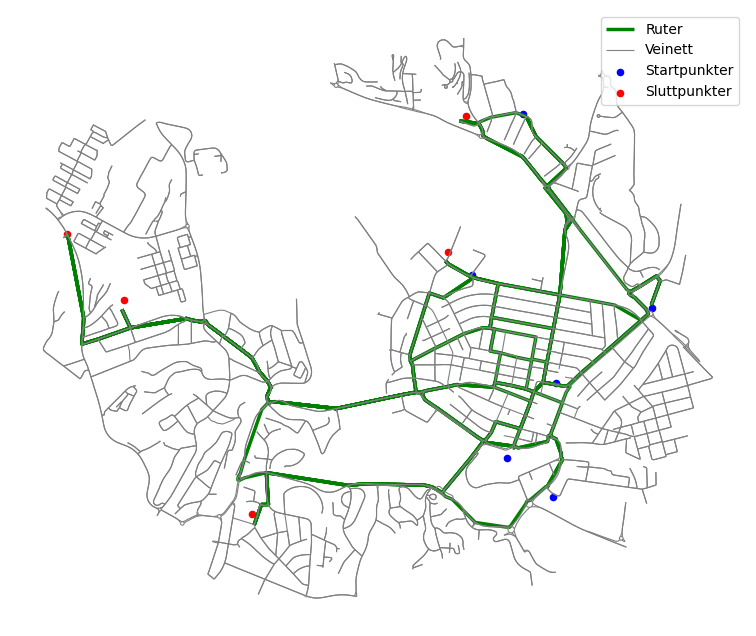

In [41]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

# Plotter alle rutene over veinettet
fig, ax = plt.subplots(figsize=(12,8))

ruter.plot(ax=ax, linewidth=2.5, color="green", label="Ruter")
edges.plot(ax=ax, linewidth=0.8, color="grey", label="Veinett")

start.plot(ax=ax, markersize=20, color="blue", label="Startpunkter")
slutt.plot(ax=ax, markersize=20, color="red", label="Sluttpunkter")

ax.set_axis_off()
plt.legend()
plt.show()

## Oppgave 8: Total avstand

Regn ut den totale avstanden og lagre den i en variabel ved navn `total_avstand`

In [42]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

total_avstand = ruter["avstand"].sum()

In [43]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
# Print løsningen din:
print(f"Den totale avstanden av alle ruter er {round((total_avstand / 1000))} kilometer")

# Sjekk om du har samme resultat som den innebygde testen.
# Ikke få panikk om du får feil her, koden din kan være riktig, men at du har brukt et litt annet nettverk i analysen tidligere i oppgaven.
assert 0.9*93 <= round(total_avstand/1000) <= 1.1*93, "Your solution doesn't match the model solution."

Den totale avstanden av alle ruter er 95 kilometer


## Ferdig!

Gratulerer, du er nå ferdig med siste øvingsoppgave, da er det bare prosjektoppgaven som gjenstår!